In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
policy = pd.read_csv("../data/external/states_sports_betting_legalization.csv")
state_monthly = pd.read_csv("../data/processed/helpline_monthly.csv")
state_monthly.rename(columns={"caller_state": "State"}, inplace=True)
policy["Online Launch"] = pd.to_datetime(policy["Online Launch"],format='%Y-%m', errors='coerce')
policy["Retail Launch"] = pd.to_datetime(policy["Retail Launch"],format='%Y-%m', errors='coerce')
state_monthly["date"] = pd.to_datetime(state_monthly["date"])

In [3]:
# Remove dropped states from both policy and helpline panel
policy_clean = policy[policy['Treatment Group'] != 'Dropped'].copy()
state_monthly = state_monthly[state_monthly['State'].isin(policy_clean['State'])].copy().reset_index(drop=True)
state_monthly = state_monthly[
    (state_monthly['date'] >= '2016-01-01') &
    (state_monthly['date'] <= '2025-12-01')
].copy()
print(state_monthly['State'].nunique())  # should be 47

print(state_monthly.shape)              # should be 47 × 120 = 5,640 rows
print(state_monthly.duplicated(subset=['State', 'date']).sum())  # should be 0
state_monthly.rename(columns={'caller_state': 'State'}, inplace=True)
state_monthly = state_monthly.sort_values(['State', 'date']).reset_index(drop=True)

47
(5448, 5)
0


# Outages and Missing Values

In [4]:
state_monthly['date'] = pd.to_datetime(state_monthly['date'])

full_index = pd.MultiIndex.from_product(
    [policy_clean['State'].unique(), pd.date_range('2016-01-01', '2025-12-01', freq='MS')],
    names=['State', 'date']
)

full_df = pd.DataFrame(index=full_index).reset_index()
missing = full_df.merge(state_monthly[['State', 'date']], on=['State', 'date'], how='left', indicator=True)
missing = missing[missing['_merge'] == 'left_only']

print(missing.shape)
print(missing.groupby('date').size().sort_values(ascending=False).to_string())
missing[missing["date"] == "2018-11-01"]

(192, 3)
date
2018-08-01    47
2018-12-01    47
2020-04-01    47
2020-08-01    47
2018-03-01     1
2018-04-01     1
2018-07-01     1
2018-11-01     1


,State,date,_merge
4474,South Dakota,2018-11-01,left_only


In [5]:
# Drop South Dakota
state_monthly = state_monthly[state_monthly['State'] != 'South Dakota'].copy()
policy_clean = policy_clean[policy_clean['State'] != 'South Dakota'].copy()

# Reindex to full balanced panel (46 states × 120 months = 5,520)
full_index = pd.MultiIndex.from_product(
    [policy_clean['State'].unique(), pd.date_range('2016-01-01', '2025-12-01', freq='MS')],
    names=['State', 'date']
)
panel = pd.DataFrame(index=full_index).reset_index()
panel = panel.merge(state_monthly[['State', 'date', 'total_contacts']], on=['State', 'date'], how='left')

full_outages = ['2018-08-01', '2018-12-01', '2020-04-01', '2020-08-01']
partial_outages = ['2016-02-01', '2022-09-01']

panel['data_quality'] = 'ok'
panel.loc[panel['date'].isin(pd.to_datetime(full_outages)), 'data_quality'] = 'full_outage'
panel.loc[panel['date'].isin(pd.to_datetime(partial_outages)), 'data_quality'] = 'partial_outage'

panel = panel.sort_values(['State', 'date']).reset_index(drop=True)

panel['total_contacts'] = (
    panel.groupby('State')['total_contacts']
    .transform(lambda x: x.interpolate(method='linear', limit_area='inside'))
)

# Verify no NaNs remain
print(panel['total_contacts'].isna().sum())

0


# Population

In [6]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}
panel["State"] = panel["State"].map(state_abbrev)
pop = pd.read_csv("../data/external/historical_state_population_by_year.csv", header=None, names=["State", "year", "Population"])
panel["year"] = panel['date'].dt.year
panel = panel.merge(pop, on=['State', 'year'], how='left')
panel['contacts_per_100k'] = panel['total_contacts'] / panel['Population'] * 100000

In [7]:
print(panel.shape)                          # should still be 5,520
print(panel['Population'].isna().sum())     # should be 0 
print(panel['contacts_per_100k'].isna().sum())  # should be 0

(5520, 7)
0
0


# Treatment Variables

In [8]:
policy_clean['State'] = policy_clean['State'].map(state_abbrev)
policy_clean['first_launch'] = policy_clean[['Retail Launch', 'Online Launch']].min(axis=1)

In [9]:
print(policy_clean[['State', 'Treatment Group', 'Retail Launch', 'Online Launch', 'first_launch']])

   State        Treatment Group Retail Launch Online Launch first_launch
0     AL  Never-Treated Control           NaT           NaT          NaT
1     AK  Never-Treated Control           NaT           NaT          NaT
2     AZ                Treated    2021-09-01    2021-09-01   2021-09-01
3     AR                Treated    2019-07-01    2022-03-01   2019-07-01
4     CA  Never-Treated Control           NaT           NaT          NaT
5     CO                Treated    2020-05-01    2020-05-01   2020-05-01
6     CT                Treated    2021-10-01    2021-10-01   2021-10-01
7     DE  Never-Treated Control           NaT           NaT          NaT
9     GA  Never-Treated Control           NaT           NaT          NaT
10    HI  Never-Treated Control           NaT           NaT          NaT
11    ID  Never-Treated Control           NaT           NaT          NaT
12    IL                Treated    2020-03-01    2020-06-01   2020-03-01
13    IN                Treated    2019-09-01    20

In [10]:
# Merge policy into panel
panel = panel.merge(
    policy_clean[['State', 'Treatment Group', 'first_launch', 'Retail Launch', 'Online Launch']],
    on='State',
    how='left'
)

# Treatment indicator: 1 if date >= first_launch (and state is treated)
panel['treated'] = (
    (panel['Treatment Group'] == 'Treated') &
    (panel['date'] >= panel['first_launch'])
).astype(int)

# Months relative to treatment (for event study)
panel['months_to_treatment'] = (
    (panel['date'].dt.year - panel['first_launch'].dt.year) * 12 +
    (panel['date'].dt.month - panel['first_launch'].dt.month)
)

panel['first_treat_period'] = (
    (panel['first_launch'].dt.year - 2016) * 12 + panel['first_launch'].dt.month
).fillna(0).astype(int)
panel['period'] = (
    (panel['date'].dt.year - 2016) * 12 + panel['date'].dt.month
)
print(panel.shape)          
print(panel['treated'].value_counts())
print(panel[panel['Treatment Group'] == 'Treated'][['State', 'date', 'first_launch', 'treated', 'months_to_treatment','first_treat_period', 'period']].head(20))

(5520, 15)
treated
0    3927
1    1593
Name: count, dtype: int64
    State       date first_launch  treated  months_to_treatment  \
240    AZ 2016-01-01   2021-09-01        0                -68.0   
241    AZ 2016-02-01   2021-09-01        0                -67.0   
242    AZ 2016-03-01   2021-09-01        0                -66.0   
243    AZ 2016-04-01   2021-09-01        0                -65.0   
244    AZ 2016-05-01   2021-09-01        0                -64.0   
245    AZ 2016-06-01   2021-09-01        0                -63.0   
246    AZ 2016-07-01   2021-09-01        0                -62.0   
247    AZ 2016-08-01   2021-09-01        0                -61.0   
248    AZ 2016-09-01   2021-09-01        0                -60.0   
249    AZ 2016-10-01   2021-09-01        0                -59.0   
250    AZ 2016-11-01   2021-09-01        0                -58.0   
251    AZ 2016-12-01   2021-09-01        0                -57.0   
252    AZ 2017-01-01   2021-09-01        0                -56.0 

## Panel Plots

In [11]:
# Handle outliers
wy_p99 = panel[panel['State'] == 'WY']['contacts_per_100k'].quantile(0.99)
panel.loc[(panel['State'] == 'WY') & (panel['date'] == '2016-01-01'), 
          'contacts_per_100k'] = wy_p99

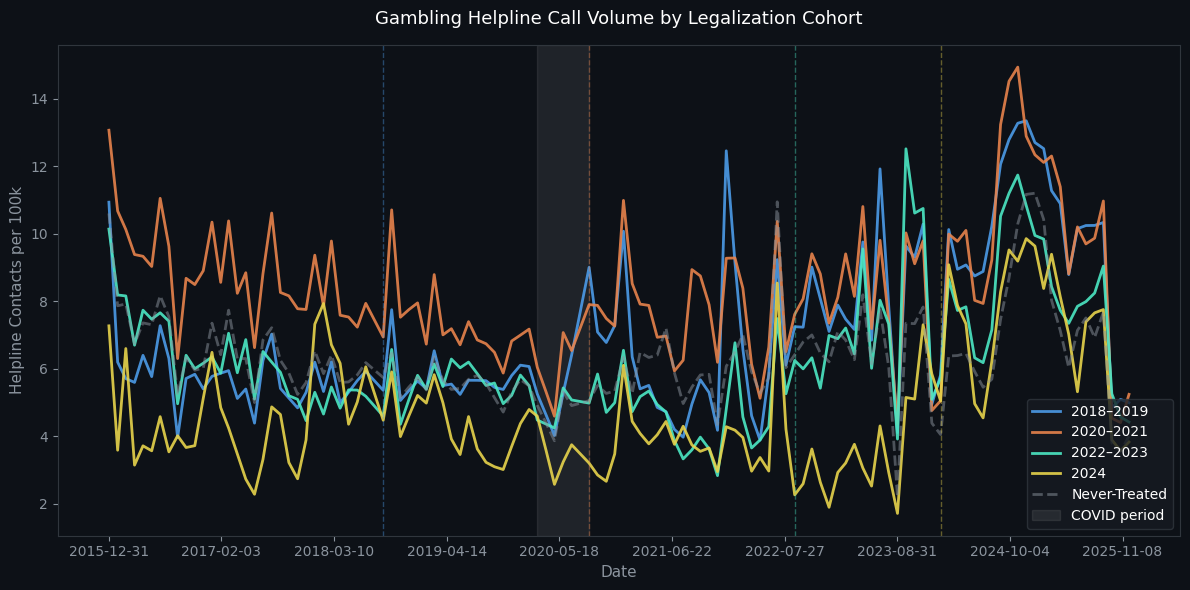

In [12]:
def assign_cohort(first_launch):
    if pd.isna(first_launch):
        return 'Never-Treated'
    year = pd.to_datetime(first_launch).year
    if year <= 2019:
        return '2018–2019'
    elif year <= 2021:
        return '2020–2021'
    elif year <= 2023:
        return '2022–2023'
    else:
        return '2024'
panel["date"] = pd.to_datetime(panel["date"])
panel['cohort'] = panel['first_launch'].map(assign_cohort)


cohort_means = (
    panel.groupby(['cohort', 'date'])['contacts_per_100k']
    .mean()
    .reset_index()
)


DARK_NAVY   = '#0d1117'
STEEL_BLUE  = '#4C9BE8'
WARM_ORANGE = '#E8834C'
TEAL        = '#4CE8C4'
GOLD        = '#E8D44C'
LIGHT_GRAY  = '#8B949E'

cohort_order  = ['2018–2019', '2020–2021', '2022–2023', '2024', 'Never-Treated']
cohort_colors = {
    '2018–2019':    STEEL_BLUE,
    '2020–2021':    WARM_ORANGE,
    '2022–2023':    TEAL,
    '2024':         GOLD,
    'Never-Treated': LIGHT_GRAY,
}


onset_dates = {
    '2018–2019': pd.Timestamp('2018-09-01'),
    '2020–2021': pd.Timestamp('2020-09-01'),
    '2022–2023': pd.Timestamp('2022-09-01'),
    '2024':      pd.Timestamp('2024-02-01'),
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_NAVY)
ax.set_facecolor(DARK_NAVY)

for cohort in cohort_order:
    df = cohort_means[cohort_means['cohort'] == cohort]
    ax.plot(df['date'], df['contacts_per_100k'], linewidth=2,
            color=cohort_colors[cohort], label=cohort,
            alpha=0.9 if cohort != 'Never-Treated' else 0.5,
            linestyle='-' if cohort != 'Never-Treated' else '--')

for cohort, date in onset_dates.items():
    ax.axvline(x=date, color=cohort_colors[cohort],
               linestyle='--', linewidth=1, alpha=0.4)


ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.08, color='white', label='COVID period')

ax.set_xlabel('Date', color=LIGHT_GRAY, fontsize=11)
ax.set_ylabel('Helpline Contacts per 100k', color=LIGHT_GRAY, fontsize=11)
ax.set_title('Gambling Helpline Call Volume by Legalization Cohort',
             color='white', fontsize=13, pad=15)

ax.tick_params(colors=LIGHT_GRAY)
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

ax.legend(facecolor='#161b22', edgecolor='#30363d',
          labelcolor='white', fontsize=10,loc='lower right')

plt.tight_layout()
plt.show()

In [13]:
pre_paspa = panel[panel['date'] <= '2018-04-01']

baseline = (
    pre_paspa.groupby('State')['contacts_per_100k']
    .mean()
    .reset_index()
    .rename(columns={'contacts_per_100k': 'baseline_contacts_per_100k'})
)

panel = panel.merge(baseline, on='State', how='left')


print(panel['baseline_contacts_per_100k'].isna().sum())

0


In [14]:
panel.to_csv('../data/processed/panel.csv', index=False)
print("Saved:", panel.shape)


Saved: (5520, 17)
